In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv('eval/model_vs_labels.csv')
df['match'] = df['label_sentiment'] == df['model_sentiment']
print(f"Total comments: {len(df)}")
print(f"Sentiment matches: {df['match'].sum()} / {len(df)} ({df['match'].mean():.1%})")

Total comments: 58
Sentiment matches: 38 / 58 (65.5%)


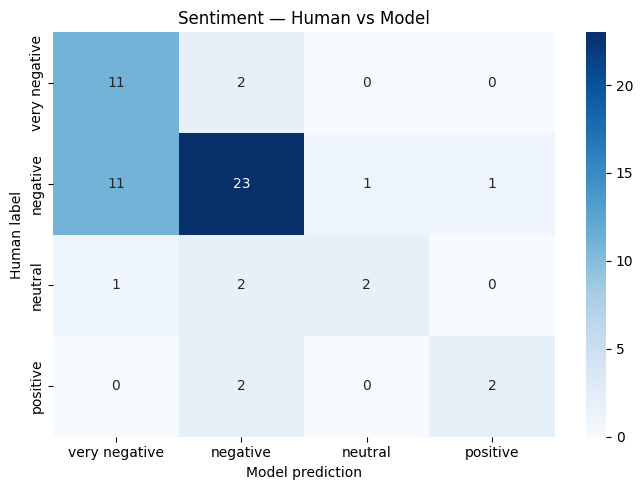

In [2]:
# Confusion matrix
labels = ['very negative', 'negative', 'neutral', 'positive', 'very positive']
present = [l for l in labels if l in df['label_sentiment'].values or l in df['model_sentiment'].values]

cm = confusion_matrix(df['label_sentiment'], df['model_sentiment'], labels=present)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present, yticklabels=present, ax=ax)
ax.set_xlabel('Model prediction')
ax.set_ylabel('Human label')
ax.set_title('Sentiment — Human vs Model')
plt.tight_layout()
plt.show()

In [3]:
# Full comparison table — all 58 comments
view = df[['comments', 'label_sentiment', 'model_sentiment', 'match', '_annotator', 'label_tickers']].copy()
view['comments'] = view['comments'].str[:120] + '...'

def color_row(row):
    bg = 'background-color: #d4edda' if row['match'] else 'background-color: #f8d7da'
    return [bg] * len(row)

pd.set_option('display.max_colwidth', 120)
view.style.apply(color_row, axis=1)

,comments,label_sentiment,model_sentiment,match,_annotator,label_tickers
0,"Not only is he able to do that, but when he took over Chipotle in 2018 he uprooted the entire corporation from Denver an...",negative,very negative,False,nan,CMG
1,Time to sell my TSLA stock....,negative,negative,True,nan,TSLA
2,[https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authorizati...,negative,positive,False,nan,GM
3,Just sent an email to Starbucks through their Contact Us online. It’s a pain in the ass to get to. “Hello l’d like to le...,negative,very negative,False,nan,SBUX
4,"The local Chipotle has a lot of 1-star reviews lately. They all mention the same thing - lack of cleanliness, and extre...",negative,negative,True,nan,CMG
5,DAMN!!! Chipotle invoked the wrath of Keith Lee.....HANG IT UP!!!!! SHEESH!!!!...,negative,very negative,False,nan,CMG
6,">But boosting portion sizes at those Chipotle locations will make a dent in the chain's financial results, with CFO John...",negative,very negative,False,Alice_labeled,CMG
7,"My wife and I ordered online from Chipotle recently, and laughed at the tiny ass burritos we got that cost over $25 for ...",very negative,very negative,True,Alice_labeled,CMG
8,"Funny how the guy comes from Taco Bell via Chipotle to Starbucks, which all three happen to be companies I think sell sh...",very negative,very negative,True,Alice_labeled,"CMG, YUM, SBUX"
9,Oh no…right after the r/wallstreetbets post: “I just bought 700k worth of Intel Stock”...,very negative,negative,False,Alice_labeled,INTC


In [4]:
# Mismatches only — full comment text
mismatches = df[~df['match']][['comments', 'label_sentiment', 'model_sentiment', '_annotator', 'label_tickers']].copy()
print(f"{len(mismatches)} mismatches out of {len(df)} comments\n")

for i, row in mismatches.iterrows():
    print(f"--- #{i} | Human: {row['label_sentiment']} | Model: {row['model_sentiment']} | Labeled by: {row['_annotator']} ---")
    print(row['comments'][:500])
    print()

20 mismatches out of 58 comments

--- #0 | Human: negative | Model: very negative | Labeled by: nan ---
Not only is he able to do that, but when he took over Chipotle in 2018 he uprooted the entire corporation from Denver and moved it out to his home base in Newport.

The company at the time was in the process of moving into a brand new high-rise in downtown Denver.  After the move they were required to pay dead rent on this multi million dollar facility all for his convenience,  moving the company closer to where he and his former Taco Bell executives lived (several of which he later poached from

--- #2 | Human: negative | Model: positive | Labeled by: nan ---
[https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authorization](https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authorization)



`GM Board Approves New $6 Billion Share Repurchase Authorization`

`Tue, June 1

In [5]:
# Per-annotator accuracy — who agrees most with the model?
per_annotator = df.groupby('_annotator')['match'].agg(['sum', 'count'])
per_annotator['accuracy'] = per_annotator['sum'] / per_annotator['count']
per_annotator.columns = ['correct', 'total', 'accuracy']
per_annotator['accuracy'] = per_annotator['accuracy'].map('{:.1%}'.format)
print(per_annotator.sort_values('correct', ascending=False))

                   correct  total accuracy
_annotator                                
Jovan_labeled           10     12    83.3%
Pierpaolo_labeled       10     15    66.7%
Francesco_labeled        7      8    87.5%
Alice_labeled            5      8    62.5%
Sergio_labeled           4      9    44.4%


In [6]:
simple = df[['comments', 'label_sentiment', 'model_sentiment',
  '_annotator']].copy()
simple.columns = ['comment', 'human_label', 'llm_label', 'annotator']
simple['comment'] = simple['comment'].str[:150] + '...'
simple

,comment,human_label,llm_label,annotator
0,"Not only is he able to do that, but when he took over Chipotle in 2018 he uprooted the entire corporation from Denve...",negative,very negative,NaN
1,Time to sell my TSLA stock....,negative,negative,NaN
2,[https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authori...,negative,positive,NaN
3,Just sent an email to Starbucks through their Contact Us online. It’s a pain in the ass to get to.\n“Hello l’d like ...,negative,very negative,NaN
4,"The local Chipotle has a lot of 1-star reviews lately. They all mention the same thing - lack of cleanliness, and e...",negative,negative,NaN
5,DAMN!!! Chipotle invoked the wrath of Keith Lee.....HANG IT UP!!!!! SHEESH!!!!...,negative,very negative,NaN
6,">But boosting portion sizes at those Chipotle locations will make a dent in the chain's financial results, with CFO ...",negative,very negative,Alice_labeled
7,"My wife and I ordered online from Chipotle recently, and laughed at the tiny ass burritos we got that cost over $25 ...",very negative,very negative,Alice_labeled
8,"Funny how the guy comes from Taco Bell via Chipotle to Starbucks, which all three happen to be companies I think sel...",very negative,very negative,Alice_labeled
9,Oh no…right after the r/wallstreetbets post: “I just bought 700k worth of Intel Stock”...,very negative,negative,Alice_labeled


## Export — v1 Baseline Artifacts
Run this section to save versioned PNG + CSV snapshots for the presentation.
After tuning the SYSTEM_PROMPT, re-run `score_eval.py --run-model`, update
the CSV path below to `v2_`, and re-run to get the comparison artifacts.

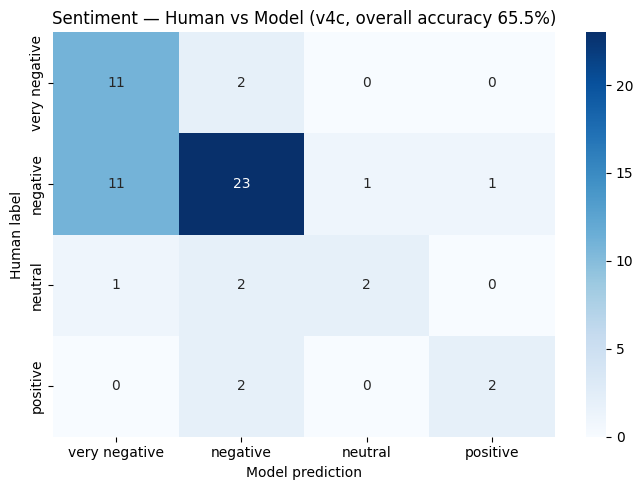

Saved: eval/v4c_confusion_matrix.png


In [7]:
from pathlib import Path
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import confusion_matrix

VERSION = 'v4c'  # change to 'v2', 'v3', etc. after each tuning round
EVAL_DIR = Path('eval')

df = pd.read_csv('eval/model_vs_labels.csv')
df['match'] = df['label_sentiment'] == df['model_sentiment']

LABEL_ORDER = ['very negative', 'negative', 'neutral', 'positive', 'very positive']
present = [l for l in LABEL_ORDER
           if l in df['label_sentiment'].values or l in df['model_sentiment'].values]

# ── 1. Confusion matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(df['label_sentiment'], df['model_sentiment'], labels=present)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present, yticklabels=present, ax=ax)
ax.set_xlabel('Model prediction')
ax.set_ylabel('Human label')
accuracy = df['match'].mean()
ax.set_title(f'Sentiment — Human vs Model ({VERSION}, overall accuracy {accuracy:.1%})')
plt.tight_layout()
out = EVAL_DIR / f'{VERSION}_confusion_matrix.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')


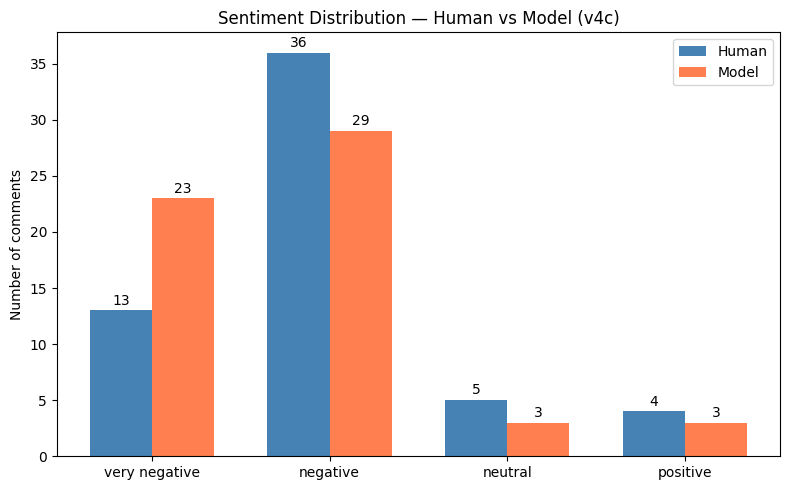

Saved: eval/v4c_sentiment_distribution.png


In [8]:
# ── 2. Sentiment distribution: human vs model ────────────────────────────────
human_counts = df['label_sentiment'].value_counts().reindex(present, fill_value=0)
model_counts = df['model_sentiment'].value_counts().reindex(present, fill_value=0)

x = range(len(present))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], human_counts, width, label='Human', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], model_counts, width, label='Model', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(present)
ax.set_ylabel('Number of comments')
ax.set_title(f'Sentiment Distribution — Human vs Model ({VERSION})')
ax.legend()
ax.bar_label(bars1, padding=2)
ax.bar_label(bars2, padding=2)
plt.tight_layout()
out = EVAL_DIR / f'{VERSION}_sentiment_distribution.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')


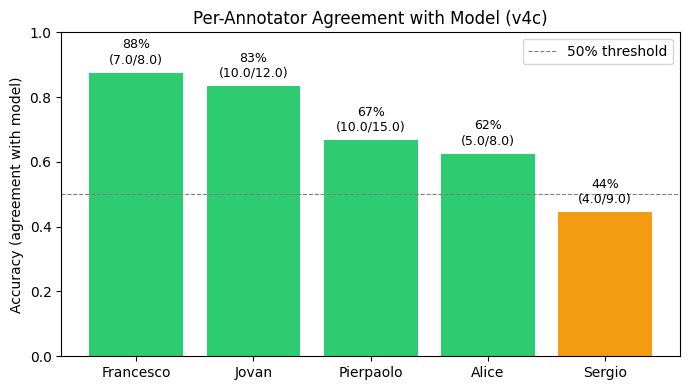

Saved: eval/v4c_per_annotator_accuracy.png


In [9]:
# ── 3. Per-annotator accuracy bar chart ──────────────────────────────────────
per_ann = (df.groupby('_annotator')['match']
             .agg(correct='sum', total='count')
             .assign(accuracy=lambda x: x['correct'] / x['total'])
             .sort_values('accuracy', ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71' if v >= 0.5 else '#e74c3c' if v < 0.25 else '#f39c12'
          for v in per_ann['accuracy']]
bars = ax.bar(per_ann.index.str.replace('_labeled', ''), per_ann['accuracy'], color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy (agreement with model)')
ax.set_title(f'Per-Annotator Agreement with Model ({VERSION})')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.legend()
for bar, (_, row) in zip(bars, per_ann.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['accuracy']:.0%}\n({row['correct']}/{row['total']})",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
out = EVAL_DIR / f'{VERSION}_per_annotator_accuracy.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')


In [10]:
# ── 4. Classification report CSV (precision / recall / F1 per class) ─────────
report = classification_report(
    df['label_sentiment'], df['model_sentiment'],
    labels=present, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T.round(3)
out = EVAL_DIR / f'{VERSION}_classification_report.csv'
report_df.to_csv(out)
print(f'Saved: {out}')
print(report_df.to_string())


Saved: eval/v4c_classification_report.csv
               precision  recall  f1-score  support
very negative      0.478   0.846     0.611   13.000
negative           0.793   0.639     0.708   36.000
neutral            0.667   0.400     0.500    5.000
positive           0.667   0.500     0.571    4.000
accuracy           0.655   0.655     0.655    0.655
macro avg          0.651   0.596     0.598   58.000
weighted avg       0.703   0.655     0.659   58.000
